<a href="https://colab.research.google.com/github/Vickytoreeya/Vic-Token/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D,
    MaxPooling2D, SimpleRNN, LSTM, GRU, Embedding,
    BatchNormalization, Input, LayerNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

%matplotlib inline
print("Tensorflow version", tf.__version__)
print("Numpy version", np.__version__)
print("Setup complete - all libraries loaded successfully!")

Tensorflow version 2.20.0
Numpy version 2.0.2
Setup complete - all libraries loaded successfully!


In [ ]:
# ---- Demostration: Early stopping and Regularization ---
from tensorflow.keras.regularizers import l2

# Generate synthetic classification data
np.random.seed(42)
X_demo = np.random.randn(500, 10)
y_demo = (X_demo[:, 0] + X_demo[:, 1] * 0.5 + np.random.randn(500) * 0.3 > 0).astype(int)
X_tr, X_val, y_tr, y_val = train_test_split(X_demo, y_demo, test_size = 0.2, random_state=42)

In [ ]:
# Build model WITH L2 regularization and Early Stopping (brain of the AI)
model_reg = Sequential([
    Dense(64,  activation='relu', kernel_regularizer=l2(0.01), input_shape=(10,)), BatchNormalization(),
    # (It normalizes the outputs of hidden layers during training before passing them to the )
    Dropout(0.3),        # Dropout layer (you know this)
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from re import VERBOSE

#Early Stopping callback - stops if val_loss dosen't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

#Learning Rate Reducer - automatically reduces learning rate when progress stalls
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

print("Training with L2 regularization, BatchNorm, Dropout, and Early Stopping ...")

history = model_reg.fit(
    X_tr, y_tr,
    epochs = 200,      #Set high - Early Stopping will handle when to Stop
    batch_size = 32,
    validation_data=(X_val, y_val),
    callbacks = [early_stop, lr_reducer],
    verbose = 0
)

Training with L2 regularization, BatchNorm, Dropout, and Early Stopping ...

Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 68: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 68: early stopping
Restoring model weights from the end of the best epoch: 58.


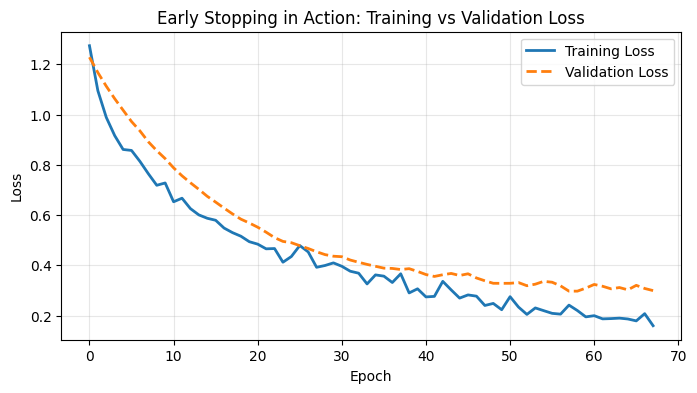


final Validation Accuracy: (final_acc*100:.1f)%
Training stopped at epoch 68 (out of 200 max)


In [ ]:
#plot training vs validation loss to visualize early stopping

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.title("Early Stopping in Action: Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_acc = model_reg.evaluate(X_val, y_val, verbose=0)[1]
print(f"\nfinal Validation Accuracy: (final_acc*100:.1f)%")
print(f"Training stopped at epoch {len(history.history['loss'])} (out of 200 max)")

In [ ]:
#Stock Price Prediction with LSTM


#1. Generate synthetic stock price data (realistc random walk)

np.random.seed(42)
n_days = 500
price_changes = np.random.randn(n_days) * 2 + 0.05       #small upward drift
stock_prices = 100 + np.cumsum(price_changes)      #cummulative sum = price series
stock_prices = np.maximum(stock_prices, 10)      #

print(stock_prices)
print(price_changes)

[101.04342831 100.8168997  102.16227678 105.25833649 104.84002974
 104.42175583 107.63018146 109.21505092 108.32610215 109.46122223
 108.58438685 107.70292734 108.23685188 104.4602914  101.06045573
  99.98588067  98.01021843  98.6887131   96.92266494  94.14805754
  97.12935508  96.72780248  96.91285889  94.11336252  93.07459707
  93.34644225  91.09445509  91.89585113  90.74457375  90.21118625
  89.05777302  92.81232939  92.83533494  90.76991309  92.46500291
  90.07331561  90.5410428   86.67170255  84.06533045  84.50905293
  86.03598609  86.42872265  86.24742608  85.69521869  82.78817471
  81.3984863   80.52720875  82.69145321  83.42868979  79.95260947
  80.65077741  79.93061285  78.62676885  79.90012143  82.01212047
  83.92468071  82.29624567  81.72782091  82.44034778  84.44143803
  83.53308956  83.2117716   81.04910165  78.70668841  80.38174005
  83.14422011  83.05019987  85.10726566  85.88053771  84.6402982
  85.41308941  88.53916255  88.51751047  91.69679778  86.50730757
  88.201112

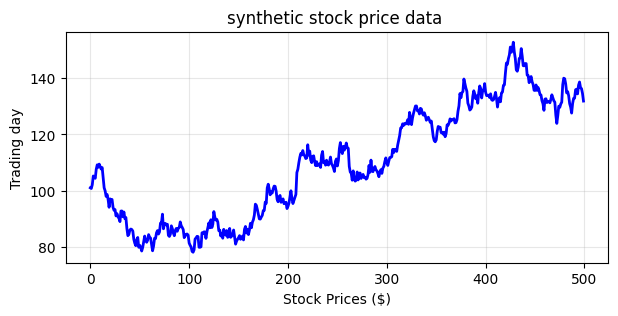

Price range: $(stock_prices.min():.2f) - $(stock_prices.max():.2f)


In [ ]:
#plot STP vs LSTM

plt.figure(figsize=(7, 3))
plt.plot(stock_prices, color= 'blue', linewidth=2)
plt.ylabel('Trading day')
plt.xlabel("Stock Prices ($)")
plt.title("synthetic stock price data ")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Price range: $(stock_prices.min():.2f) - $(stock_prices.max():.2f)")


In [ ]:
# 2. Create sequences: use the last 30 days to predict the next day's price

WINDOW_SIZE = 30

# Normalize prices to [0, 1] using Min-Max scaling
scaler_stock = MinMaxScaler()
prices_scaled = scaler_stock.fit_transform(stock_prices.reshape(-1, 1)).flatten()

# Create sliding window sequences
X_seq, y_seq = [], []
for i in range(WINDOW_SIZE, len(prices_scaled)):
    X_seq.append(prices_scaled[i - WINDOW_SIZE:i])
    y_seq.append(prices_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Reshape for LSTM: (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], WINDOW_SIZE, 1)

In [ ]:
#split into train/test (first 80% for training)

split = int(len(X_seq) * 0.8)
X_train_s, X_test_s = X_seq[:split], X_seq[split:]
y_train_s, y_test_s = y_seq[:split], y_seq[split:]

print(f"Training sequences: {X_train_s.shape}")
print(f"Test sequences: {X_test_s.shape}")
print(f"Each sequence: {WINDOW_SIZE} days -> predict day {WINDOW_SIZE+1}")

Training sequences: (376, 30, 1)
Test sequences: (94, 30, 1)
Each sequence: 30 days -> predict day 31


In [ ]:
#Build and train the LSTM model

model_lstm = Sequential([
    LSTM(50, activation= 'tanh', input_shape=(WINDOW_SIZE, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)       #single output: predicted next-day price
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

Lets_Train = model_lstm.fit(
    X_train_s, y_train_s,
    epochs = 20,
    batch_size = 32,
    validation_data=(X_test_s, y_test_s),
    verbose = 1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0597 - val_loss: 0.0367
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120 - val_loss: 0.0300
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0072 - val_loss: 0.0048
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0046 - val_loss: 0.0053
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0041 - val_loss: 0.0056
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0041 - val_loss: 0.0060
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0040 - val_loss: 0.0042
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0044 - val_loss: 0.0050
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


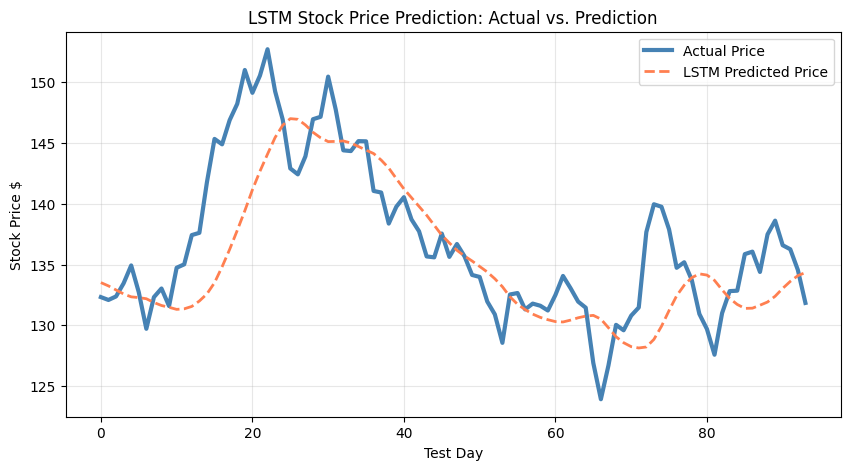

Test MSE: (mse_stock:.4f)
Test RMSE: $(np.sqrt(mse_stock):.2f)


In [ ]:
#predict and visualize result

predictions_scaled = model_lstm.predict(X_test_s)
predictions = scaler_stock.inverse_transform(predictions_scaled)
actual = scaler_stock.inverse_transform(y_test_s.reshape(-1,1))

plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual Price', color='steelblue', linewidth=3)
plt.plot(predictions, label='LSTM Predicted Price', color='coral', linewidth=2, linestyle='--')
plt.title("LSTM Stock Price Prediction: Actual vs. Prediction")
plt.xlabel("Test Day")
plt.ylabel("Stock Price $")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mse_stock = mean_squared_error(actual, predictions)
print(f"Test MSE: (mse_stock:.4f)")
print(f"Test RMSE: $(np.sqrt(mse_stock):.2f)")